In [17]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

# ---------------------------------------------------------------------------
# Canonical condition × sex palette for ALL non-UMAP analysis plots.
# Edit here once and every Sankey / chord / heatmap downstream picks it up.
# UMAPs are explicitly excluded (scanpy palettes drive those).
# ---------------------------------------------------------------------------
SEX_CONDITION_PALETTE = {
    ('M', 'WT'): '#004a99',  # Control male
    ('M', 'KO'): '#90bff9',  # SkM-KO male
    ('F', 'WT'): '#f71480',  # Control female
    ('F', 'KO'): '#fa98c7',  # SkM-KO female
}

# Sex-only collapse (used when a plot isn't split by condition — picks WT shade).
SEX_PALETTE = {
    'F': SEX_CONDITION_PALETTE[('F', 'KO')],
    'M': SEX_CONDITION_PALETTE[('M', 'KO')],
}

In [19]:
adata_whole = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot.h5ad')

## Cell proportions
#### Showing quantification of population shifts between WT and KO

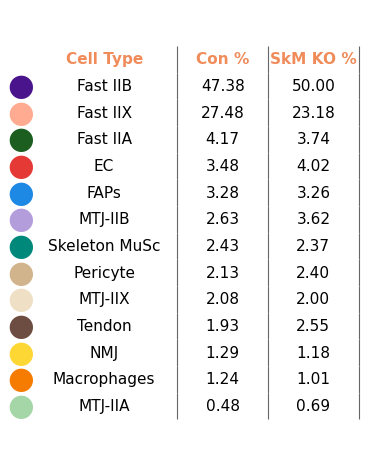

In [20]:
adata_re = adata_whole.copy()

# Pull palette from uns
re_annot_palette = dict(zip(
    adata_re.obs["re_annot"].cat.categories,
    adata_re.uns.get(
        "re_annot_colors",
        plt.cm.tab20.colors[:len(adata_re.obs["re_annot"].cat.categories)],
    ),
))

comp = (
    pd.crosstab(adata_re.obs["re_annot"], adata_re.obs["condition"], normalize="columns")
    * 100
).round(2).rename(columns={"WT": "Con %", "KO": "SkM KO %"})
comp = comp.sort_values("Con %", ascending=False)

# ── TABLE ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, len(comp) * 0.4 + 0.6))
ax.axis("off")

cell_text = [
    ["●", ct, f"{comp.loc[ct, 'Con %']:.2f}", f"{comp.loc[ct, 'SkM KO %']:.2f}"]
    for ct in comp.index
]
tbl = ax.table(
    cellText=cell_text,
    colLabels=["", "Cell Type", "Con %", "SkM KO %"],
    loc="center", cellLoc="center",
    colWidths=[0.06, 0.42, 0.26, 0.26],
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.6)

# Strip everything: no borders, no background fills
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("white")
    cell.visible_edges = ""

# Vertical separators bracketing the two number columns
for r in range(len(comp) + 1):           # include header row
    tbl[r, 2].visible_edges = "L"        # line at left of Con %
    tbl[r, 3].visible_edges = "LR"       # line between Con % and SkM KO %, and right of SkM KO %
    for col in (2, 3):
        tbl[r, col].set_linewidth(0.8)
        tbl[r, col].set_edgecolor("#666666")

# Headers: orange text, no fill
for i in range(4):
    tbl[0, i].set_text_props(color="#F08C5A", fontweight="bold")

# Colored dots
for r, ct in enumerate(comp.index, start=1):
    dot = tbl[r, 0].get_text()
    dot.set_color(re_annot_palette.get(ct, "#888888"))
    dot.set_fontsize(22)
    dot.set_fontweight("bold")

#fig.savefig(f"{figures_dir}/celltype_table_wt_vs_ko.svg", bbox_inches="tight")
plt.show()

#### Sankey plot for splitting by sex

In [21]:
df = adata_whole.obs.groupby(['sex', 're_annot']).size().reset_index(name='count')

# rename sex_condition to group
# df = df.rename(columns={'sex_condition': 'group'})
df = df.rename(columns={'sex': 'group'})
# rename re_annot to cell_type
df = df.rename(columns={'re_annot': 'cell_type'})
display(df.head())

,group,cell_type,count
0,F,Fast IIB,19339
1,F,Fast IIX,12505
2,F,Fast IIA,1906
3,F,EC,1468
4,F,FAPs,1119


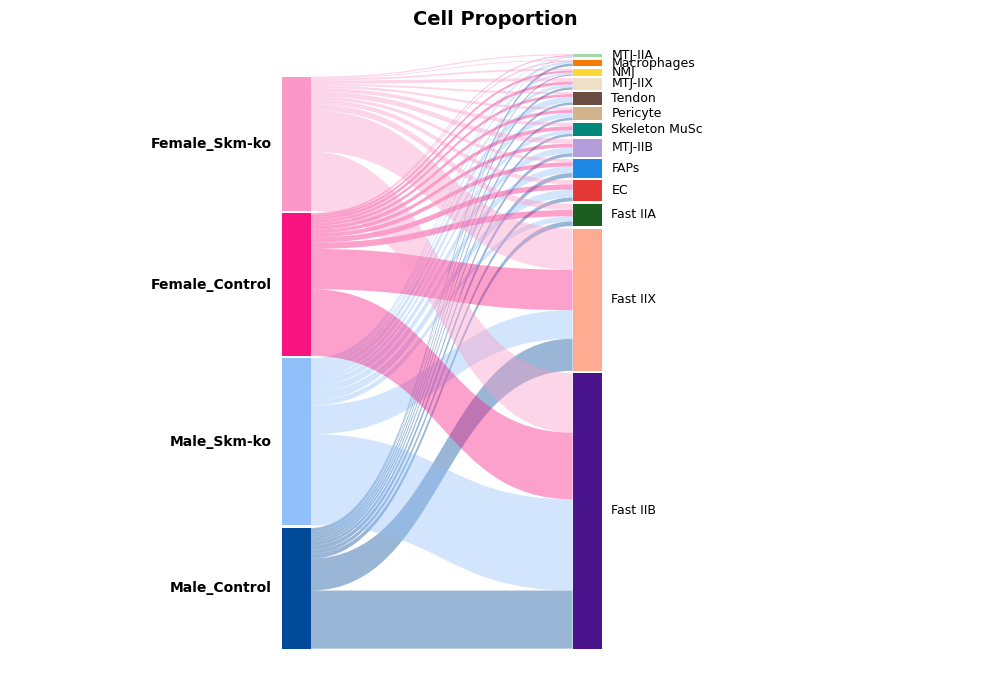

In [22]:
import matplotlib.pyplot as plt
import pygenelab as pgl

LEFT_COL  = 'group'        # sex × condition (4 levels)
RIGHT_COL = 're_annot'

# scanpy cell type colors — auto-pulled or define manually
cell_type_colors = dict(zip(
    adata_whole.obs[RIGHT_COL].cat.categories,
    adata_whole.uns.get(
        f'{RIGHT_COL}_colors',
        plt.cm.tab20.colors[:len(adata_whole.obs[RIGHT_COL].cat.categories)],
    ),
))

# sex × condition → display label (matches user-requested naming)
SEX_COND_LABELS = {
    ('M', 'WT'): 'Male_Control',
    ('M', 'KO'): 'Male_Skm-ko',
    ('F', 'WT'): 'Female_Control',
    ('F', 'KO'): 'Female_Skm-ko',
}
GROUP_ORDER = ['Male_Control', 'Male_Skm-ko', 'Female_Control', 'Female_Skm-ko']
GROUP_COLORS = {
    'Male_Control':   SEX_CONDITION_PALETTE[('M', 'WT')],
    'Male_Skm-ko':    SEX_CONDITION_PALETTE[('M', 'KO')],
    'Female_Control': SEX_CONDITION_PALETTE[('F', 'WT')],
    'Female_Skm-ko':  SEX_CONDITION_PALETTE[('F', 'KO')],
}

# Build a per-nucleus DataFrame with the combined group label (don't mutate
# adata_whole.obs — the derived col is only needed for this plot).
df_plot = adata_whole.obs[['sex', 'condition', RIGHT_COL]].copy()
df_plot['group'] = [
    SEX_COND_LABELS[(s, c)] for s, c in zip(df_plot['sex'], df_plot['condition'])
]

fig, ax = pgl.plot_sankey(
    data=df_plot,
    left_col=LEFT_COL,
    right_col=RIGHT_COL,
    left_order=GROUP_ORDER,
    left_colors=GROUP_COLORS,
    right_colors=cell_type_colors,
    title='Cell Proportion',
)

#fig.savefig(f'{figures_dir}/sankey_sex_condition_to_cell_type.svg', **figure_params)
plt.show()

  chord rows: 26
re_annot  Fast IIB  Fast IIX  Fast IIA    EC  FAPs  MTJ-IIB  Skeleton MuSc  \
sex                                                                          
F            19339     12505      1906  1468  1119     1310           1144   
M            22923      9314      1508  1795  1711     1426            933   

re_annot  Pericyte  Tendon  MTJ-IIX  NMJ  Macrophages  MTJ-IIA  
sex                                                             
F              830     707      977  606          238      321  
M             1140    1251      790  460          730      190  


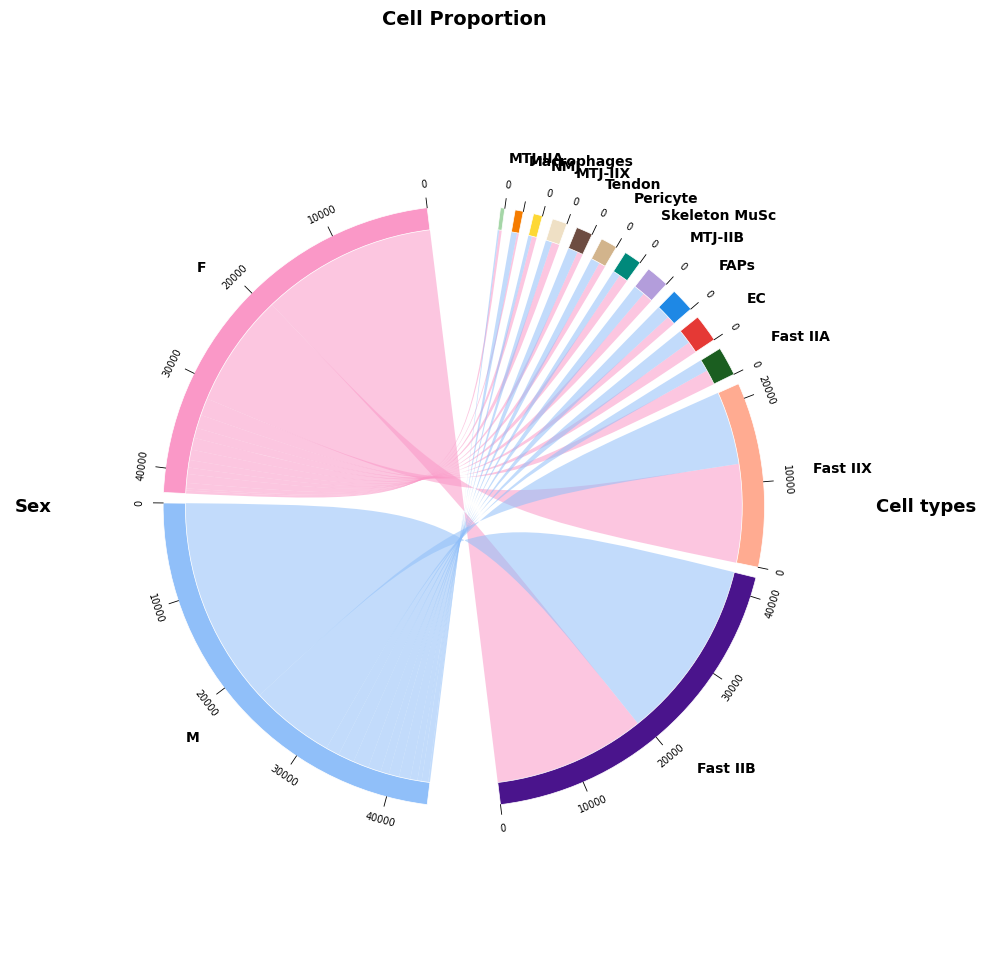

In [25]:
# Chord (circular Sankey) view of the sex × cell-type proportions.
# Sex-only on the left arc (no WT/KO split — that's only in the Sankey above),
# cell types on the right arc, ribbon widths = nucleus counts. Reuses the
# scanpy cell-type palette and the canonical SEX_PALETTE (WT shades).

# Use the submodule path (pgl.plotting.plot_chord) instead of the star-imported
# alias (pgl.plot_chord) — autoreload can't add new top-level names to a
# namespace that was already populated by `from .plotting import *` at import
# time, so star-imported aliases for newly-added functions can be stale until
# the kernel is restarted.
from pygenelab import plotting as pgl_plotting

CHORD_LEFT_COL  = 'sex'
CHORD_RIGHT_COL = RIGHT_COL          # 're_annot' from the Sankey cell above

# sex × cell-type nucleus counts (one row per sex/cell-type pair)
chord_counts = (
    adata_whole.obs.groupby([CHORD_LEFT_COL, CHORD_RIGHT_COL], observed=True)
    .size()
    .reset_index(name='n_nuclei')
)
print(f"  chord rows: {len(chord_counts)}")
print(
    chord_counts.pivot(index=CHORD_LEFT_COL, columns=CHORD_RIGHT_COL, values='n_nuclei')
    .reindex(['F', 'M'])
    .fillna(0)
    .astype(int)
)

cell_type_order = list(adata_whole.obs[CHORD_RIGHT_COL].cat.categories)

chord_fig, chord_ax = pgl_plotting.plot_chord(
    chord_counts,
    left_col=CHORD_LEFT_COL,
    right_col=CHORD_RIGHT_COL,
    count_col='n_nuclei',
    left_order=['F', 'M'],
    right_order=cell_type_order,
    left_colors=SEX_PALETTE,         # canonical F=#f71480, M=#004a99 (WT shades)
    right_colors=cell_type_colors,   # reuse the scanpy cell-type palette from the sankey
    flow_color='left',               # ribbons inherit the sex color
    left_axis_label='Sex',
    right_axis_label='Cell types',
    show_ticks=True,
    tick_step='auto',                # auto-pick a 1/2/5*10^k step per side so the
                                     # largest segment shows ~5 ticks; override with
                                     # an int or (left, right) tuple / dict if needed
    min_tick_label_gap_deg=4.0,      # suppress tick labels that crowd each other
    segment_label_pad=0.18,          # push cell-type names outside the tick numbers
    title='Cell Proportion',
)
chord_fig.savefig(f'{figures_dir}/chord_M_F_to_cell_type.svg', **figure_params)
plt.show()
